# 02 — Exploração e Tratamento dos Dados do MapBiomas Solo

## Projeto AgroESG

Este notebook realiza a ingestão, exploração, validação, limpeza,
padronização e preparação dos dados de estoque de carbono orgânico
do solo obtidos a partir do MapBiomas Solo — Coleção 3.

Os dados foram originalmente processados no Google Earth Engine,
utilizando os mapas anuais de estoque de carbono orgânico do solo
e a malha municipal do IBGE.

O pipeline segue a arquitetura:

RAW → PROCESSED → CURATED

### RAW
Preserva o arquivo originalmente exportado do Google Earth Engine.

### PROCESSED
Realiza padronização de colunas, tipos de dados, regiões,
estrutura temporal e validações de qualidade.

### CURATED
Aplica os recortes e regras de negócio utilizados pelo projeto
AgroESG, preparando a base para integração com dados agrícolas,
climáticos e ambientais.

Período analisado: 2019–2024.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DIR = (
    BASE_DIR
    / "data"
    / "raw"
    / "mapbiomas_solo"
)

PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "databases_processed"
    / "mapbiomas_solo"
)

CURATED_DIR = (
    BASE_DIR
    / "data"
    / "databases_curated"
    / "mapbiomas_solo"
)

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("CURATED_DIR:", CURATED_DIR)

BASE_DIR: C:\Users\Elaine Cristina\Downloads\agroesg-analytics
RAW_DIR: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\raw\mapbiomas_solo
PROCESSED_DIR: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_processed\mapbiomas_solo
CURATED_DIR: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_curated\mapbiomas_solo


In [3]:
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CURATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Pastas verificadas/criadas.")

Pastas verificadas/criadas.


In [4]:
arquivos_csv = list(
    RAW_DIR.glob("*.csv")
)

print("Arquivos CSV encontrados:")

for arquivo in arquivos_csv:
    print("-", arquivo.name)

Arquivos CSV encontrados:
- mapbiomas_solo_municipios_2019_2024.csv


In [5]:
assert len(arquivos_csv) == 1, (
    f"Esperado 1 CSV em RAW, mas foram encontrados {len(arquivos_csv)}."
)

arquivo_solo = arquivos_csv[0]

print("Arquivo selecionado:")
print(arquivo_solo)

Arquivo selecionado:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\raw\mapbiomas_solo\mapbiomas_solo_municipios_2019_2024.csv


In [6]:
with open(
    arquivo_solo,
    "r",
    encoding="utf-8-sig"
) as arquivo:

    for _ in range(5):
        print(arquivo.readline().strip())

CD_MUN,NM_MUN,SIGLA_UF,SIGLA_RG,AREA_KM2,carbon_2019,carbon_2020,carbon_2021,carbon_2022,carbon_2023,carbon_2024
1100809,Candeias do Jamari,RO,N,6843.673,51.94071586310387,51.93509275428738,49.16212452579384,49.30049107412873,49.34409990752619,49.3435248227234
1100205,Porto Velho,RO,N,34091.146,50.216082082144766,50.198799208267616,47.48922579361337,47.54580288690579,47.53643745418669,47.534657665016844
1101104,Itapuã do Oeste,RO,N,4081.581,51.627402292725755,51.5937535019492,48.149729181130375,48.16510057560811,48.16232968606879,48.151291955545524
1100940,Cujubim,RO,N,3863.946,51.05088459655176,50.99935471361586,49.17297610989846,49.31717215408514,49.344381191770395,49.34354927403538


In [7]:
solo_raw = pd.read_csv(
    arquivo_solo,
    encoding="utf-8-sig",
    dtype={
        "CD_MUN": "string"
    }
)

solo_raw.head()

,CD_MUN,NM_MUN,SIGLA_UF,SIGLA_RG,AREA_KM2,carbon_2019,carbon_2020,carbon_2021,carbon_2022,carbon_2023,carbon_2024
0,1100809,Candeias do Jamari,RO,N,6843.673,51.940716,51.935093,49.162125,49.300491,49.344100,49.343525
1,1100205,Porto Velho,RO,N,34091.146,50.216082,50.198799,47.489226,47.545803,47.536437,47.534658
2,1101104,Itapuã do Oeste,RO,N,4081.581,51.627402,51.593754,48.149729,48.165101,48.162330,48.151292
3,1100940,Cujubim,RO,N,3863.946,51.050885,50.999355,49.172976,49.317172,49.344381,49.343549
4,1100403,Alto Paraíso,RO,N,2651.991,49.768994,49.738707,48.641477,48.667624,48.739085,48.735749


In [8]:
print(
    "Dimensão da base:",
    solo_raw.shape
)

print(
    "Linhas:",
    solo_raw.shape[0]
)

print(
    "Colunas:",
    solo_raw.shape[1]
)

Dimensão da base: (5573, 11)
Linhas: 5573
Colunas: 11


In [9]:
print("Colunas:")

for coluna in solo_raw.columns:
    print("-", coluna)

Colunas:
- CD_MUN
- NM_MUN
- SIGLA_UF
- SIGLA_RG
- AREA_KM2
- carbon_2019
- carbon_2020
- carbon_2021
- carbon_2022
- carbon_2023
- carbon_2024


In [10]:
solo_raw.dtypes

CD_MUN         string[python]
NM_MUN                 object
SIGLA_UF               object
SIGLA_RG               object
AREA_KM2              float64
carbon_2019           float64
carbon_2020           float64
carbon_2021           float64
carbon_2022           float64
carbon_2023           float64
carbon_2024           float64
dtype: object

In [11]:
print(
    "Municípios:",
    solo_raw["CD_MUN"].nunique()
)

print(
    "UFs:",
    solo_raw["SIGLA_UF"].nunique()
)

print(
    "Regiões:",
    sorted(
        solo_raw["SIGLA_RG"].unique()
    )
)

Municípios: 5573
UFs: 27
Regiões: ['CO', 'N', 'NE', 'S', 'SE']


In [12]:
duplicados_municipios = (
    solo_raw
    .duplicated(
        subset=["CD_MUN"]
    )
    .sum()
)

print(
    "Municípios duplicados:",
    duplicados_municipios
)

Municípios duplicados: 0


In [13]:
nulos_raw = (
    solo_raw
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

nulos_raw

carbon_2019    1
carbon_2020    1
carbon_2021    1
carbon_2022    1
carbon_2023    1
carbon_2024    1
CD_MUN         0
NM_MUN         0
SIGLA_UF       0
SIGLA_RG       0
AREA_KM2       0
dtype: int64

In [14]:
colunas_carbono = [
    coluna
    for coluna in solo_raw.columns
    if coluna.startswith("carbon_")
]

solo_raw[
    solo_raw[colunas_carbono]
    .isna()
    .any(axis=1)
]

,CD_MUN,NM_MUN,SIGLA_UF,SIGLA_RG,AREA_KM2,carbon_2019,carbon_2020,carbon_2021,carbon_2022,carbon_2023,carbon_2024
1068,2605459,Fernando de Noronha,PE,NE,18.609,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# 15. Estatísticas descritivas das colunas de carbono

solo_raw[
    colunas_carbono
].describe().T

,count,mean,std,min,25%,50%,75%,max
carbon_2019,5572.0,47.370602,12.851366,0.000000,36.432632,48.043797,55.270450,118.757438
carbon_2020,5572.0,47.370413,12.820982,0.000000,36.430254,48.046346,55.216694,118.384410
carbon_2021,5572.0,46.556319,12.740428,0.016557,35.684172,46.797956,54.553213,117.857364
carbon_2022,5572.0,46.579158,12.686740,0.000000,35.792876,46.784877,54.544941,117.578616
carbon_2023,5572.0,46.639626,12.613397,0.000000,35.901978,46.774773,54.546595,117.607143
carbon_2024,5572.0,46.623266,12.611706,0.000000,35.890295,46.759094,54.530642,117.150444


In [16]:
# 16. Verificar valores negativos

for coluna in colunas_carbono:
    negativos = (solo_raw[coluna] < 0).sum()

    print(
        coluna,
        "-> negativos:",
        negativos
    )

carbon_2019 -> negativos: 0
carbon_2020 -> negativos: 0
carbon_2021 -> negativos: 0
carbon_2022 -> negativos: 0
carbon_2023 -> negativos: 0
carbon_2024 -> negativos: 0


## Diagnóstico inicial da camada RAW

A base contém uma observação por município e seis variáveis anuais
de estoque médio de carbono orgânico do solo, referentes ao período
de 2019 a 2024.

Foram verificadas:

- dimensão da base;
- quantidade de municípios;
- abrangência estadual e regional;
- unicidade do código municipal;
- tipos das variáveis;
- valores ausentes;
- valores negativos;
- distribuição inicial dos valores de carbono.

Foi identificado um município com ausência de informação de carbono
para todo o período analisado: Fernando de Noronha (PE).

Os valores ausentes foram preservados como `NaN`, pois ausência de
informação não representa necessariamente estoque de carbono igual
a zero.

A camada RAW permanece preservada sem alterações.

In [17]:
solo_processado = solo_raw.copy()

solo_processado.head()

,CD_MUN,NM_MUN,SIGLA_UF,SIGLA_RG,AREA_KM2,carbon_2019,carbon_2020,carbon_2021,carbon_2022,carbon_2023,carbon_2024
0,1100809,Candeias do Jamari,RO,N,6843.673,51.940716,51.935093,49.162125,49.300491,49.344100,49.343525
1,1100205,Porto Velho,RO,N,34091.146,50.216082,50.198799,47.489226,47.545803,47.536437,47.534658
2,1101104,Itapuã do Oeste,RO,N,4081.581,51.627402,51.593754,48.149729,48.165101,48.162330,48.151292
3,1100940,Cujubim,RO,N,3863.946,51.050885,50.999355,49.172976,49.317172,49.344381,49.343549
4,1100403,Alto Paraíso,RO,N,2651.991,49.768994,49.738707,48.641477,48.667624,48.739085,48.735749


## 17. Construção da camada PROCESSED

A partir desta etapa, é criada uma cópia da base RAW para aplicação das transformações de limpeza, normalização e padronização.

A camada RAW permanece preservada sem alterações.

In [18]:
solo_processado = solo_processado.rename(
    columns={
        "CD_MUN": "codigo_ibge",
        "NM_MUN": "municipio",
        "SIGLA_UF": "uf",
        "SIGLA_RG": "regiao",
        "AREA_KM2": "area_km2"
    }
)

solo_processado.columns

Index(['codigo_ibge', 'municipio', 'uf', 'regiao', 'area_km2', 'carbon_2019',
       'carbon_2020', 'carbon_2021', 'carbon_2022', 'carbon_2023',
       'carbon_2024'],
      dtype='object')

In [19]:
solo_processado["codigo_ibge"] = (
    solo_processado["codigo_ibge"]
    .astype("string")
    .str.strip()
)

solo_processado["municipio"] = (
    solo_processado["municipio"]
    .astype("string")
    .str.strip()
)

solo_processado["uf"] = (
    solo_processado["uf"]
    .astype("string")
    .str.strip()
)

solo_processado["regiao"] = (
    solo_processado["regiao"]
    .astype("string")
    .str.strip()
)

solo_processado["area_km2"] = pd.to_numeric(
    solo_processado["area_km2"],
    errors="coerce"
)

solo_processado.dtypes

codigo_ibge    string[python]
municipio      string[python]
uf             string[python]
regiao         string[python]
area_km2              float64
carbon_2019           float64
carbon_2020           float64
carbon_2021           float64
carbon_2022           float64
carbon_2023           float64
carbon_2024           float64
dtype: object

In [20]:
colunas_id = [
    "codigo_ibge",
    "municipio",
    "uf",
    "regiao",
    "area_km2"
]

colunas_carbono = [
    "carbon_2019",
    "carbon_2020",
    "carbon_2021",
    "carbon_2022",
    "carbon_2023",
    "carbon_2024"
]

solo_processado = solo_processado.melt(
    id_vars=colunas_id,
    value_vars=colunas_carbono,
    var_name="carbono_ano",
    value_name="carbono_solo_t_ha"
)

solo_processado.head(10)

,codigo_ibge,municipio,uf,regiao,area_km2,carbono_ano,carbono_solo_t_ha
0,1100809,Candeias do Jamari,RO,N,6843.673,carbon_2019,51.940716
1,1100205,Porto Velho,RO,N,34091.146,carbon_2019,50.216082
2,1101104,Itapuã do Oeste,RO,N,4081.581,carbon_2019,51.627402
3,1100940,Cujubim,RO,N,3863.946,carbon_2019,51.050885
4,1100403,Alto Paraíso,RO,N,2651.991,carbon_2019,49.768994
5,1100130,Machadinho D'Oeste,RO,N,8509.270,carbon_2019,49.894309
6,1101757,Vale do Anari,RO,N,3135.106,carbon_2019,49.701469
7,1200401,Rio Branco,AC,N,8834.831,carbon_2019,48.433592
8,1200138,Bujari,AC,N,3035.547,carbon_2019,49.498604
9,1200179,Capixaba,AC,N,1705.236,carbon_2019,46.320218


In [21]:
solo_processado["ano"] = (
    solo_processado["carbono_ano"]
    .str.extract(r"(\d{4})")[0]
    .astype("int64")
)

solo_processado = solo_processado.drop(
    columns="carbono_ano"
)

solo_processado.head()

,codigo_ibge,municipio,uf,regiao,area_km2,carbono_solo_t_ha,ano
0,1100809,Candeias do Jamari,RO,N,6843.673,51.940716,2019
1,1100205,Porto Velho,RO,N,34091.146,50.216082,2019
2,1101104,Itapuã do Oeste,RO,N,4081.581,51.627402,2019
3,1100940,Cujubim,RO,N,3863.946,51.050885,2019
4,1100403,Alto Paraíso,RO,N,2651.991,49.768994,2019


In [22]:
solo_processado = solo_processado[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        "ano",
        "area_km2",
        "carbono_solo_t_ha"
    ]
].copy()

solo_processado.head(10)

,codigo_ibge,municipio,uf,regiao,ano,area_km2,carbono_solo_t_ha
0,1100809,Candeias do Jamari,RO,N,2019,6843.673,51.940716
1,1100205,Porto Velho,RO,N,2019,34091.146,50.216082
2,1101104,Itapuã do Oeste,RO,N,2019,4081.581,51.627402
3,1100940,Cujubim,RO,N,2019,3863.946,51.050885
4,1100403,Alto Paraíso,RO,N,2019,2651.991,49.768994
5,1100130,Machadinho D'Oeste,RO,N,2019,8509.270,49.894309
6,1101757,Vale do Anari,RO,N,2019,3135.106,49.701469
7,1200401,Rio Branco,AC,N,2019,8834.831,48.433592
8,1200138,Bujari,AC,N,2019,3035.547,49.498604
9,1200179,Capixaba,AC,N,2019,1705.236,46.320218


In [23]:
print(
    "Dimensão processada:",
    solo_processado.shape
)

print(
    "Municípios:",
    solo_processado["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(
        solo_processado["ano"].unique()
    )
)

print(
    "UFs:",
    solo_processado["uf"].nunique()
)

print(
    "Regiões:",
    solo_processado["regiao"].unique()
)

Dimensão processada: (33438, 7)
Municípios: 5573
Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
UFs: 27
Regiões: <StringArray>
['N', 'NE', 'SE', 'CO', 'S']
Length: 5, dtype: string


In [24]:
duplicados = (
    solo_processado
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano"
        ]
    )
    .sum()
)

print(
    "Duplicados na chave município-ano:",
    duplicados
)

Duplicados na chave município-ano: 0


In [25]:
solo_processado.isna().sum().sort_values(
    ascending=False
)

carbono_solo_t_ha    6
codigo_ibge          0
municipio            0
uf                   0
regiao               0
ano                  0
area_km2             0
dtype: int64

In [26]:
solo_processado.isna().sum().sort_values(
    ascending=False
)

carbono_solo_t_ha    6
codigo_ibge          0
municipio            0
uf                   0
regiao               0
ano                  0
area_km2             0
dtype: int64

In [27]:
negativos = (
    solo_processado["carbono_solo_t_ha"] < 0
).sum()

print(
    "Valores negativos de carbono:",
    negativos
)

Valores negativos de carbono: 0


In [28]:
solo_processado[
    "carbono_solo_t_ha"
].describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99
    ]
)

count    33432.000000
mean        46.856564
std         12.725379
min          0.000000
50%         47.145694
90%         61.241219
95%         67.654313
99%         86.517038
max        118.757438
Name: carbono_solo_t_ha, dtype: float64

In [29]:
solo_processado["status_dado"] = (
    solo_processado[
        "carbono_solo_t_ha"
    ]
    .notna()
    .map({
        True: "disponivel",
        False: "dados_nao_captados"
    })
)

solo_processado[
    "status_dado"
].value_counts()

status_dado
disponivel            33432
dados_nao_captados        6
Name: count, dtype: int64

In [30]:
assert (
    solo_processado
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano"
        ]
    )
    .sum()
    == 0
)

assert (
    solo_processado[
        "ano"
    ]
    .between(
        2019,
        2024
    )
    .all()
)

assert (
    solo_processado[
        "carbono_solo_t_ha"
    ]
    .dropna()
    .ge(0)
    .all()
)

print(
    "✅ Validação da camada PROCESSED concluída."
)

✅ Validação da camada PROCESSED concluída.


## 31. Exportação da camada PROCESSED

A base processada é exportada preservando todos os municípios e anos disponíveis no escopo da fonte.

Nesta camada foram realizadas apenas operações de limpeza, normalização, padronização estrutural e validação de qualidade.

In [31]:
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Elaine Cristina\Downloads\agroesg-analytics")

PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "processed"
    / "mapbiomas_solo"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

arquivo_processed = (
    PROCESSED_DIR
    / "mapbiomas_solo_municipios_2019_2024_processed.csv"
)

solo_processado.to_csv(
    arquivo_processed,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo em:")
print(arquivo_processed)

Arquivo salvo em:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\processed\mapbiomas_solo\mapbiomas_solo_municipios_2019_2024_processed.csv


## 32. Construção da camada CURATED

A camada CURATED representa o conjunto preparado para utilização analítica no projeto AgroESG.

Nesta etapa são aplicadas as regras de negócio do projeto:

- período de análise: 2019–2024;
- abrangência nacional;
- granularidade município-ano;
- manutenção das cinco macrorregiões brasileiras;
- preservação explícita dos registros sem informação de carbono.

In [32]:
solo_curated = (
    solo_processado[
        solo_processado["ano"].between(
            2019,
            2024
        )
    ]
    .copy()
)

solo_curated.head()

,codigo_ibge,municipio,uf,regiao,ano,area_km2,carbono_solo_t_ha,status_dado
0,1100809,Candeias do Jamari,RO,N,2019,6843.673,51.940716,disponivel
1,1100205,Porto Velho,RO,N,2019,34091.146,50.216082,disponivel
2,1101104,Itapuã do Oeste,RO,N,2019,4081.581,51.627402,disponivel
3,1100940,Cujubim,RO,N,2019,3863.946,51.050885,disponivel
4,1100403,Alto Paraíso,RO,N,2019,2651.991,49.768994,disponivel


In [33]:
mapa_regioes = {
    "N": "Norte",
    "NE": "Nordeste",
    "SE": "Sudeste",
    "S": "Sul",
    "CO": "Centro-Oeste"
}

solo_curated["regiao"] = (
    solo_curated["regiao"]
    .replace(mapa_regioes)
    .astype("string")
)

solo_curated["regiao"].value_counts()

regiao
Nordeste        10764
Sudeste         10008
Sul              7158
Centro-Oeste     2808
Norte            2700
Name: count, dtype: Int64

In [34]:
print(
    "Dimensão:",
    solo_curated.shape
)

print(
    "Municípios:",
    solo_curated["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(
        solo_curated["ano"].unique()
    )
)

print(
    "UFs:",
    solo_curated["uf"].nunique()
)

print(
    "Regiões:",
    solo_curated["regiao"].unique()
)

print(
    "\nStatus dos dados:"
)

print(
    solo_curated["status_dado"]
    .value_counts(dropna=False)
)

Dimensão: (33438, 8)
Municípios: 5573
Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
UFs: 27
Regiões: <StringArray>
['Norte', 'Nordeste', 'Sudeste', 'Centro-Oeste', 'Sul']
Length: 5, dtype: string

Status dos dados:
status_dado
disponivel            33432
dados_nao_captados        6
Name: count, dtype: int64


In [35]:
assert (
    solo_curated
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano"
        ]
    )
    .sum()
    == 0
)

assert (
    solo_curated["ano"]
    .between(2019, 2024)
    .all()
)

assert (
    solo_curated["uf"]
    .nunique()
    == 27
)

assert (
    solo_curated["regiao"]
    .nunique()
    == 5
)

assert (
    solo_curated[
        "carbono_solo_t_ha"
    ]
    .dropna()
    .ge(0)
    .all()
)

print(
    "✅ Validação da camada CURATED concluída."
)

✅ Validação da camada CURATED concluída.


In [37]:
# ==========================================
# 1. SALVAMENTO ANTIGO (SERÁ REMOVIDO FUTURAMENTE)
# ==========================================
CURATED_DIR = (
    BASE_DIR
    / "data"
    / "curated"
    / "mapbiomas_solo"
)

CURATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

arquivo_curated = (
    CURATED_DIR
    / "mapbiomas_solo_municipios_2019_2024_curated.csv"
)

solo_curated.to_csv(
    arquivo_curated,
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo CURATED antigo salvo em:")
print(arquivo_curated)
print("-" * 50)


# ==========================================
# 2. AJUSTANDO OS DESTINOS OFICIAIS
# ==========================================
from pathlib import Path

BASE_DIR = Path(
    r"C:\Users\Elaine Cristina\Downloads\agroesg-analytics"
)

PROCESSED_DIR_OFICIAL = (
    BASE_DIR
    / "data"
    / "databases_processed"
    / "mapbiomas_solo"
)

CURATED_DIR_OFICIAL = (
    BASE_DIR
    / "data"
    / "databases_curated"
    / "mapbiomas_solo"
)

PROCESSED_DIR_OFICIAL.mkdir(
    parents=True,
    exist_ok=True
)

CURATED_DIR_OFICIAL.mkdir(
    parents=True,
    exist_ok=True
)

print("Criando/verificando pastas oficiais:")
print(PROCESSED_DIR_OFICIAL)
print(CURATED_DIR_OFICIAL)
print("-" * 50)


# ==========================================
# 3. SALVANDO NOVAMENTE NOS DESTINOS OFICIAIS
# ==========================================
arquivo_processed_oficial = (
    PROCESSED_DIR_OFICIAL
    / "mapbiomas_solo_municipios_2019_2024_processed.csv"
)

arquivo_curated_oficial = (
    CURATED_DIR_OFICIAL
    / "mapbiomas_solo_municipios_2019_2024_curated.csv"
)

solo_processado.to_csv(
    arquivo_processed_oficial,
    index=False,
    encoding="utf-8-sig"
)

solo_curated.to_csv(
    arquivo_curated_oficial,
    index=False,
    encoding="utf-8-sig"
)

print("PROCESSSED OFICIAL:")
print(arquivo_processed_oficial)
print("\nCURATED OFICIAL:")
print(arquivo_curated_oficial)
print("-" * 50)


# ==========================================
# 4. VALIDAÇÃO
# ==========================================
print("Processed existe:", arquivo_processed_oficial.exists())
print("Curated existe:", arquivo_curated_oficial.exists())

Arquivo CURATED antigo salvo em:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\curated\mapbiomas_solo\mapbiomas_solo_municipios_2019_2024_curated.csv
--------------------------------------------------
Criando/verificando pastas oficiais:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_processed\mapbiomas_solo
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_curated\mapbiomas_solo
--------------------------------------------------
PROCESSSED OFICIAL:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_processed\mapbiomas_solo\mapbiomas_solo_municipios_2019_2024_processed.csv

CURATED OFICIAL:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_curated\mapbiomas_solo\mapbiomas_solo_municipios_2019_2024_curated.csv
--------------------------------------------------
Processed existe: True
Curated existe: True


## 37. Evolução temporal do carbono orgânico do solo

Nesta etapa é analisado o comportamento médio do estoque de carbono orgânico do solo entre 2019 e 2024.

Os cálculos são realizados exclusivamente sobre registros com informação disponível, preservando separadamente os casos classificados como `dados_nao_captados`.

In [38]:
carbono_anual = (
    solo_curated
    .groupby(
        "ano",
        as_index=False
    )
    ["carbono_solo_t_ha"]
    .mean()
)

carbono_anual

,ano,carbono_solo_t_ha
0,2019,47.370602
1,2020,47.370413
2,2021,46.556319
3,2022,46.579158
4,2023,46.639626
5,2024,46.623266


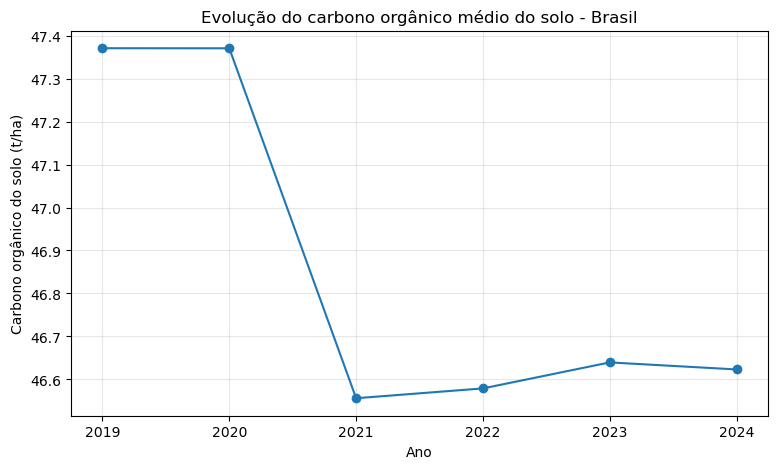

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    carbono_anual["ano"],
    carbono_anual["carbono_solo_t_ha"],
    marker="o"
)

plt.title(
    "Evolução do carbono orgânico médio do solo - Brasil"
)

plt.xlabel("Ano")
plt.ylabel("Carbono orgânico do solo (t/ha)")

plt.grid(alpha=0.3)

plt.show()

## 38. Carbono orgânico médio do solo por região

A comparação regional permite identificar diferenças espaciais no estoque médio de carbono orgânico do solo entre as cinco macrorregiões brasileiras.

In [40]:
carbono_regiao = (
    solo_curated
    .groupby(
        "regiao",
        as_index=False
    )
    ["carbono_solo_t_ha"]
    .mean()
    .sort_values(
        "carbono_solo_t_ha",
        ascending=False
    )
)

carbono_regiao

,regiao,carbono_solo_t_ha
4,Sul,56.917762
3,Sudeste,49.863446
2,Norte,47.525666
0,Centro-Oeste,43.687530
1,Nordeste,38.024174


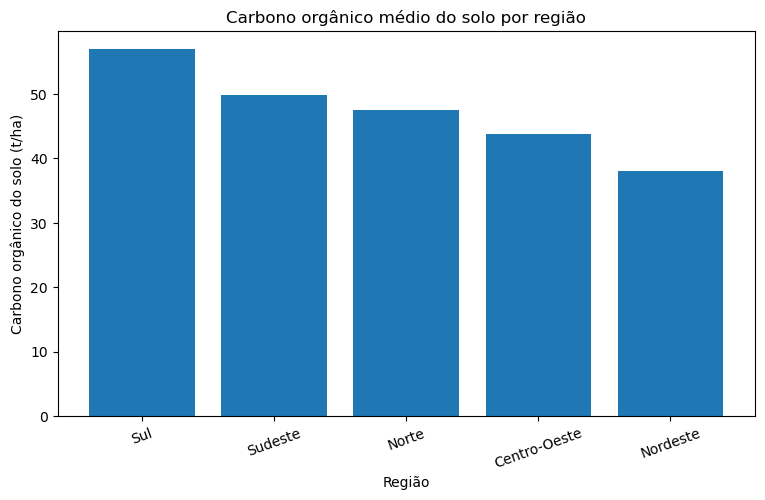

In [41]:
plt.figure(figsize=(9, 5))

plt.bar(
    carbono_regiao["regiao"],
    carbono_regiao["carbono_solo_t_ha"]
)

plt.title(
    "Carbono orgânico médio do solo por região"
)

plt.xlabel("Região")
plt.ylabel("Carbono orgânico do solo (t/ha)")

plt.xticks(rotation=20)

plt.show()

In [42]:
carbono_regiao_ano = (
    solo_curated
    .groupby(
        [
            "ano",
            "regiao"
        ],
        as_index=False
    )
    ["carbono_solo_t_ha"]
    .mean()
)

carbono_regiao_ano.head(15)

,ano,regiao,carbono_solo_t_ha
0,2019,Centro-Oeste,44.305229
1,2019,Nordeste,38.388422
2,2019,Norte,48.919313
3,2019,Sudeste,50.348845
4,2019,Sul,57.324513
5,2020,Centro-Oeste,44.282222
6,2020,Nordeste,38.456062
7,2020,Norte,48.915514
8,2020,Sudeste,50.304921
9,2020,Sul,57.293842


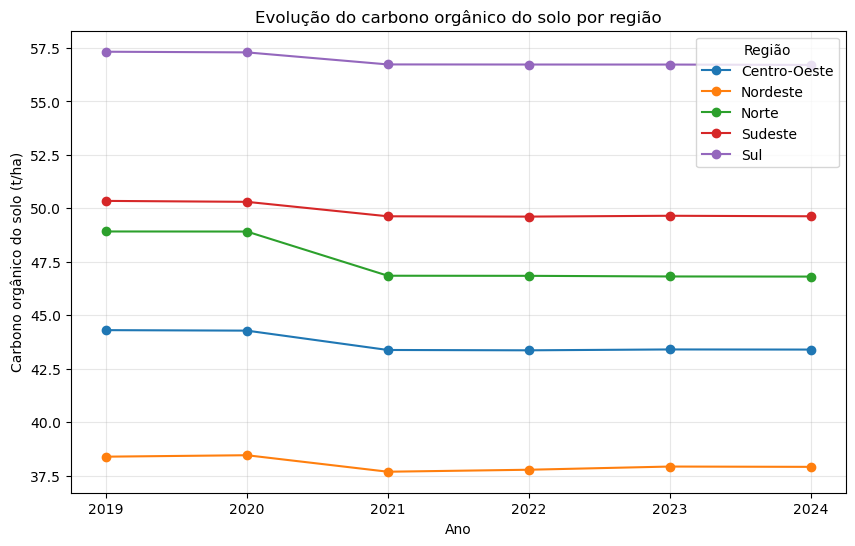

In [43]:
plt.figure(figsize=(10, 6))

for regiao in carbono_regiao_ano["regiao"].unique():

    dados = carbono_regiao_ano[
        carbono_regiao_ano["regiao"] == regiao
    ]

    plt.plot(
        dados["ano"],
        dados["carbono_solo_t_ha"],
        marker="o",
        label=regiao
    )

plt.title(
    "Evolução do carbono orgânico do solo por região"
)

plt.xlabel("Ano")
plt.ylabel("Carbono orgânico do solo (t/ha)")

plt.legend(
    title="Região"
)

plt.grid(alpha=0.3)

plt.show()

In [44]:
carbono_uf = (
    solo_curated
    .groupby(
        [
            "uf",
            "regiao"
        ],
        as_index=False
    )
    ["carbono_solo_t_ha"]
    .mean()
    .sort_values(
        "carbono_solo_t_ha",
        ascending=False
    )
)

carbono_uf

,uf,regiao,carbono_solo_t_ha
23,SC,Sul,64.230377
3,AP,Norte,63.868678
13,PA,Norte,56.204453
17,PR,Sul,55.225377
22,RS,Sul,53.947903
10,MG,Sudeste,53.282682
7,ES,Sudeste,51.410328
6,DF,Centro-Oeste,50.945644
18,RJ,Sudeste,50.560715
2,AM,Norte,49.042792


In [45]:
carbono_variacao = (
    solo_curated
    .pivot_table(
        index=[
            "codigo_ibge",
            "municipio",
            "uf",
            "regiao"
        ],
        columns="ano",
        values="carbono_solo_t_ha"
    )
    .reset_index()
)

carbono_variacao.columns.name = None

carbono_variacao.head()

,codigo_ibge,municipio,uf,regiao,2019,2020,2021,2022,2023,2024
0,1100015,Alta Floresta D'Oeste,RO,Norte,52.589022,52.665402,50.442186,50.526887,50.558089,50.557815
1,1100023,Ariquemes,RO,Norte,47.091120,46.985199,45.786885,45.860409,45.924385,45.908662
2,1100031,Cabixi,RO,Norte,41.819417,41.711695,40.871222,41.013307,41.144626,41.144544
3,1100049,Cacoal,RO,Norte,42.119137,41.988005,40.761420,41.040385,41.153691,41.151142
4,1100056,Cerejeiras,RO,Norte,56.655149,56.608491,54.113389,54.214681,54.220140,54.219451


In [46]:
carbono_variacao[
    "variacao_carbono_t_ha_2019_2024"
] = (
    carbono_variacao[2024]
    - carbono_variacao[2019]
)

In [47]:
carbono_variacao[
    "variacao_carbono_pct_2019_2024"
] = (
    (
        carbono_variacao[2024]
        - carbono_variacao[2019]
    )
    / carbono_variacao[2019]
    * 100
)

In [48]:
print(
    "Municípios com carbono = 0 em 2019:",
    (carbono_variacao[2019] == 0).sum()
)

print(
    "Municípios sem informação em 2019:",
    carbono_variacao[2019].isna().sum()
)

print(
    "Municípios sem informação em 2024:",
    carbono_variacao[2024].isna().sum()
)

Municípios com carbono = 0 em 2019: 1
Municípios sem informação em 2019: 0
Municípios sem informação em 2024: 0


In [49]:
import numpy as np

carbono_variacao[
    "variacao_carbono_pct_2019_2024"
] = np.where(
    carbono_variacao[2019] > 0,
    (
        (
            carbono_variacao[2024]
            - carbono_variacao[2019]
        )
        / carbono_variacao[2019]
        * 100
    ),
    np.nan
)

In [50]:
print(
    "Percentuais infinitos:",
    np.isinf(
        carbono_variacao[
            "variacao_carbono_pct_2019_2024"
        ]
    ).sum()
)

print(
    "Percentuais ausentes:",
    carbono_variacao[
        "variacao_carbono_pct_2019_2024"
    ].isna().sum()
)

Percentuais infinitos: 0
Percentuais ausentes: 1


## 42. Tratamento de valor inicial igual a zero

Foi identificado um município com estoque de carbono igual a zero em 2019.

Como a variação percentual exige divisão pelo valor inicial, esse registro não possui variação percentual matematicamente válida. Por isso, o campo percentual é mantido como ausente (`NaN`), enquanto a variação absoluta em t/ha permanece disponível.

In [51]:
carbono_variacao[
    carbono_variacao[2019] == 0
][
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        2019,
        2024,
        "variacao_carbono_t_ha_2019_2024",
        "variacao_carbono_pct_2019_2024"
    ]
]

,codigo_ibge,municipio,uf,regiao,2019,2024,variacao_carbono_t_ha_2019_2024,variacao_carbono_pct_2019_2024
3811,3548807,São Caetano do Sul,SP,Sudeste,0.0,0.0,0.0,NaN


In [52]:
carbono_variacao[
    [
        "variacao_carbono_t_ha_2019_2024",
        "variacao_carbono_pct_2019_2024"
    ]
].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

,variacao_carbono_t_ha_2019_2024,variacao_carbono_pct_2019_2024
count,5572.000000,5571.000000
mean,-0.747336,-1.514030
std,0.850271,1.782390
min,-6.002724,-16.716325
10%,-1.735761,-3.569263
25%,-1.020782,-2.216834
50%,-0.555623,-1.191114
75%,-0.279138,-0.549021
90%,0.017467,0.046472
95%,0.265493,0.834609


In [53]:
def classificar_variacao(valor):

    if pd.isna(valor):
        return "nao_calculavel"

    elif valor > 1:
        return "aumento"

    elif valor < -1:
        return "reducao"

    else:
        return "estavel"


carbono_variacao["classe_variacao_2019_2024"] = (
    carbono_variacao[
        "variacao_carbono_pct_2019_2024"
    ]
    .apply(classificar_variacao)
)

In [54]:
carbono_variacao[
    "classe_variacao_2019_2024"
].value_counts()

classe_variacao_2019_2024
reducao           3146
estavel           2180
aumento            245
nao_calculavel       1
Name: count, dtype: int64

In [55]:
distribuicao_variacao = (
    carbono_variacao[
        "classe_variacao_2019_2024"
    ]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="municipios")
)

distribuicao_variacao[
    "percentual"
] = (
    distribuicao_variacao["municipios"]
    / distribuicao_variacao["municipios"].sum()
    * 100
)

distribuicao_variacao

,classe,municipios,percentual
0,reducao,3146,56.460876
1,estavel,2180,39.124192
2,aumento,245,4.396985
3,nao_calculavel,1,0.017947


In [56]:
maiores_reducoes = (
    carbono_variacao
    .dropna(
        subset=[
            "variacao_carbono_pct_2019_2024"
        ]
    )
    .sort_values(
        "variacao_carbono_pct_2019_2024",
        ascending=True
    )
    [
        [
            "codigo_ibge",
            "municipio",
            "uf",
            "regiao",
            2019,
            2024,
            "variacao_carbono_t_ha_2019_2024",
            "variacao_carbono_pct_2019_2024"
        ]
    ]
    .head(20)
)

maiores_reducoes

,codigo_ibge,municipio,uf,regiao,2019,2024,variacao_carbono_t_ha_2019_2024,variacao_carbono_pct_2019_2024
3549,3525003,Jandira,SP,Sudeste,12.642424,10.529076,-2.113349,-16.716325
3387,3510609,Carapicuíba,SP,Sudeste,9.376922,7.960077,-1.416845,-15.109914
946,2304285,Eusébio,CE,Nordeste,21.689261,18.891057,-2.798204,-12.901335
3483,3519071,Hortolândia,SP,Sudeste,13.718781,12.174707,-1.544074,-11.255182
4605,4300001,"Área Operacional ""Lagoa Mirim""",RS,Sul,15.608281,13.984148,-1.624133,-10.405586
3330,3505708,Barueri,SP,Sudeste,15.651443,14.057899,-1.593544,-10.181451
3854,3552809,Taboão da Serra,SP,Sudeste,6.312314,5.721890,-0.590424,-9.353527
423,1718808,Sampaio,TO,Norte,44.619748,40.464167,-4.155581,-9.313322
135,1304401,Urucurituba,AM,Norte,64.573160,58.570436,-6.002724,-9.296004
994,2307650,Maracanaú,CE,Nordeste,18.868991,17.198698,-1.670293,-8.852052


In [57]:
maiores_aumentos = (
    carbono_variacao
    .dropna(
        subset=[
            "variacao_carbono_pct_2019_2024"
        ]
    )
    .sort_values(
        "variacao_carbono_pct_2019_2024",
        ascending=False
    )
    [
        [
            "codigo_ibge",
            "municipio",
            "uf",
            "regiao",
            2019,
            2024,
            "variacao_carbono_t_ha_2019_2024",
            "variacao_carbono_pct_2019_2024"
        ]
    ]
    .head(20)
)

maiores_aumentos

,codigo_ibge,municipio,uf,regiao,2019,2024,variacao_carbono_t_ha_2019_2024,variacao_carbono_pct_2019_2024
1002,2308351,Milhã,CE,Nordeste,30.152084,31.489851,1.337767,4.436730
1119,2404002,Frutuoso Gomes,RN,Nordeste,29.173340,30.460690,1.287350,4.412763
1166,2408409,Olho d'Água do Borges,RN,Nordeste,29.104526,30.383050,1.278524,4.392870
1154,2407252,Major Sales,RN,Nordeste,30.561612,31.902343,1.340731,4.386977
1177,2409407,Pau dos Ferros,RN,Nordeste,29.156089,30.421571,1.265482,4.340368
1189,2410504,Rafael Fernandes,RN,Nordeste,30.269929,31.561911,1.291982,4.268203
964,2305332,Ibicuitinga,CE,Nordeste,28.723986,29.943159,1.219173,4.244441
983,2306801,Jaguaribara,CE,Nordeste,28.393249,29.574421,1.181172,4.160045
911,2301802,Baixio,CE,Nordeste,30.127089,31.338905,1.211815,4.022344
1053,2312502,São João do Jaguaribe,CE,Nordeste,29.024324,30.174118,1.149793,3.961481


In [58]:
variacao_regiao = (
    carbono_variacao
    .groupby(
        "regiao",
        as_index=False
    )
    .agg(
        carbono_2019_medio=(2019, "mean"),
        carbono_2024_medio=(2024, "mean"),
        variacao_media_t_ha=(
            "variacao_carbono_t_ha_2019_2024",
            "mean"
        ),
        variacao_media_pct=(
            "variacao_carbono_pct_2019_2024",
            "mean"
        )
    )
)

variacao_regiao.sort_values(
    "variacao_media_pct"
)

,regiao,carbono_2019_medio,carbono_2024_medio,variacao_media_t_ha,variacao_media_pct
2,Norte,48.919313,46.809878,-2.109435,-4.116018
0,Centro-Oeste,44.305229,43.396407,-0.908821,-2.030258
3,Sudeste,50.348845,49.629886,-0.718959,-1.474751
4,Sul,57.324513,56.707233,-0.617280,-1.132131
1,Nordeste,38.388422,37.912156,-0.476266,-1.016870


# Conclusão

O conjunto de dados do MapBiomas Solo foi estruturado para análise do carbono orgânico do solo em escala municipal no período de 2019 a 2024.

O pipeline foi organizado seguindo a arquitetura:

**RAW → PROCESSED → CURATED**

Na camada **PROCESSED**, foram realizadas etapas de limpeza, padronização de nomes de colunas, adequação dos tipos de dados, validação de duplicidades, tratamento de valores ausentes e normalização das informações geográficas.

Na camada **CURATED**, foi aplicado o recorte temporal de 2019 a 2024 e foram mantidas as informações necessárias para as análises municipais e regionais do projeto AgroESG.

A análise exploratória mostrou diferenças relevantes entre as regiões brasileiras no estoque médio estimado de carbono orgânico do solo. O Sul apresentou os maiores valores médios, enquanto o Nordeste apresentou os menores.

Entre 2019 e 2024, a base analisada apresentou redução média municipal do carbono orgânico do solo. Utilizando uma faixa exploratória de estabilidade de ±1%, os municípios foram classificados em redução, estabilidade ou aumento.

A maior parte dos municípios apresentou redução no período, enquanto uma parcela menor apresentou aumento. Também foi identificado um município com valor inicial igual a zero, impossibilitando o cálculo matemático da variação percentual; nesse caso, o valor foi mantido como ausente, preservando a integridade analítica.

Os resultados deste notebook servirão como base para o cruzamento posterior com informações agrícolas, climáticas e ambientais, especialmente a produção municipal de soja e cana-de-açúcar da PAM/IBGE.

In [59]:
# Validação final do Notebook 02

assert solo_processado.duplicated(
    subset=["codigo_ibge", "ano"]
).sum() == 0

assert solo_curated["ano"].between(2019, 2024).all()

assert solo_curated["codigo_ibge"].notna().all()

assert solo_curated["uf"].notna().all()

assert solo_curated["regiao"].notna().all()

assert (
    solo_curated["carbono_solo_t_ha"]
    .dropna()
    .ge(0)
    .all()
)

print("✅ Notebook 02 concluído com sucesso.")
print("✅ PROCESSED validado.")
print("✅ CURATED validado.")
print("✅ Base pronta para integração com outras fontes.")

✅ Notebook 02 concluído com sucesso.
✅ PROCESSED validado.
✅ CURATED validado.
✅ Base pronta para integração com outras fontes.
